## DMRG WITH TENPY

In [7]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pickle
import os


import tenpy
from tenpy import CouplingMPOModel, SpinHalfSite
import tenpy.linalg.np_conserved as npc
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain

from scipy.optimize import curve_fit

np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150
tenpy.tools.misc.setup_logging(to_stdout="INFO")

In [8]:
L = 70

filename_master = os.path.join(os.getcwd(), f"L{L}-full")

## My MPO

In [ ]:
class myModel(CouplingMPOModel):
    def init_sites(self, model_params):
        site = SpinHalfSite(conserve=None)
        return site
    
    def init_terms(self, model_params):
        Jx = model_params.get('Jx', 1.0)
        hz = model_params.get('hz', 0.0)
        kl = model_params.get('kl', 0.0)
        kr = model_params.get('kr', 0.0)

        # Onsite magnetic field
        for u in range(len(self.lat.unit_cell)):
            self.add_onsite(hz, u, 'Sigmaz')

        # Nearest-neighbor XX coupling
        for u1, u2, dx in self.lat.pairs['nearest_neighbors']:
            self.add_coupling(Jx, u1, 'Sigmax', u2, 'Sigmax', dx)

        # 3-site interactions (already Hermitian)
        dx = [(0,), (1,), (2,)]
        u = 0  # single-site unit cell

        self.add_multi_coupling(
            kl,
            [('Sigmax', dx[0], u), ('Sigmay', dx[1], u), ('Sigmaz', dx[2], u)]
        )
        self.add_multi_coupling(
            -kl,
            [('Sigmay', dx[0], u), ('Id', dx[1], u), ('Sigmax', dx[2], u)]
        )
        self.add_multi_coupling(
            -kr,
            [('Sigmaz', dx[0], u), ('Sigmay', dx[1], u), ('Sigmax', dx[2], u)]
        )
        self.add_multi_coupling(
            kr,
            [('Sigmax', dx[0], u), ('Id', dx[1], u), ('Sigmay', dx[2], u)]
        )

        # add boundary conditions
        self.add_onsite_term(10, 0, "Sigmax")
        self.add_onsite_term(-10, L-1, "Sigmax")

def dmrg_sim(Jx, hz, kl, kr, filename):
    dmrg_params = {
    'mixer': True,  # setting this to True helps to escape local minima
    'max_E_err': 1.e-4,
    'trunc_params': {
        'chi_max': 100,
        'svd_min': 1.e-10,
    },
    'combine': True
    }

    model_params = {
    'Jx': Jx , 'hz': hz, 'kl': kl, 'kr': kr,
    'L': L,
    'bc_MPS': 'finite',
    }

    M = myModel(model_params)
    psi = MPS.from_lat_product_state(M.lat, [['up']])

    eng = dmrg.TwoSiteDMRGEngine(psi, M, dmrg_params)
    E, psi = eng.run() # the main work; modifies psi in place

    # save to file
    data = {'psi': psi, 'dmrg_params': dmrg_params, 'model_params': model_params}

    os.makedirs(filename, exist_ok=True)
        
    loc = os.path.join(filename, f'{hz:.3f}_{kl:.3f}.pkl')
    with open(loc, 'wb') as f:
        pickle.dump(data, f)
    
    return M

def dmrg_lines(start, stop, step, fixed, filename, setval="k", Jx=1):
    values = np.arange(start, stop+step, step)

    for sweep in values:
        if setval == "k":
            hz = sweep
            k = fixed
        elif setval == "h":
            hz = fixed
            k = sweep
        print(Jx, hz, k)
        M = dmrg_sim(Jx, hz, k, k, filename)
        print(M.all_coupling_terms().to_TermList() + M.all_onsite_terms().to_TermList())

h_values = [0.25, 0.5, 0.75]

for h in h_values:
    filename = os.path.join(filename_master, f"h_{h}")
    dmrg_lines(1.05, 2, 0.05, h, filename, setval="h")

1 0.25 1.05
INFO    : myModel: reading 'bc_MPS'='finite'
INFO    : myModel: reading 'L'=70
INFO    : myModel: reading 'Jx'=1
INFO    : myModel: reading 'hz'=0.25
INFO    : myModel: reading 'kl'=np.float64(1.05)
INFO    : myModel: reading 'kr'=np.float64(1.05)
INFO    : TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
INFO    : TwoSiteDMRGEngine: reading 'combine'=True
INFO    : TwoSiteDMRGEngine: reading 'mixer'=True
INFO    : activate DensityMatrixMixer with initial amplitude 1e-05
INFO    : Running sweep with optimization
INFO    : trunc_params: reading 'chi_max'=100
INFO    : trunc_params: reading 'svd_min'=1e-10
INFO    : checkpoint after sweep 1
energy=-163.0288110371347159, max S=0.6281178625557033, age=70, norm_err=3.7e-01
Current memory usage 965.0MB, wall time: 158.7s
Delta E = nan, Delta S = 5.0220e-01 (per sweep)
max trunc_err = 1.3210e-09, max E_trunc = 1.9895e-13
chi: 86
INFO    : Running sweep with optimization
INFO    : checkpoint after swe

In [ ]:
h = 1
filename = os.path.join(filename_master, f"h_{h}")
dmrg_lines(0, 1, 0.05, h, filename, setval="h")

In [ ]:
h_values = [0, 0.5, 0.75, 1]  # 40 parameter spots to look for overnight

for h in h_values:
    filename = os.path.join(filename_master, f"h_{h}")
    dmrg_lines(1.05, 2, 0.05, h, filename, setval="h")

In [ ]:
# run the same simulations with PIETROS code:

## Energy

## Magnetization Profile

/home/ioannisangelotassioulas/Documents/master_thesis/books/L70-full/h_0.5


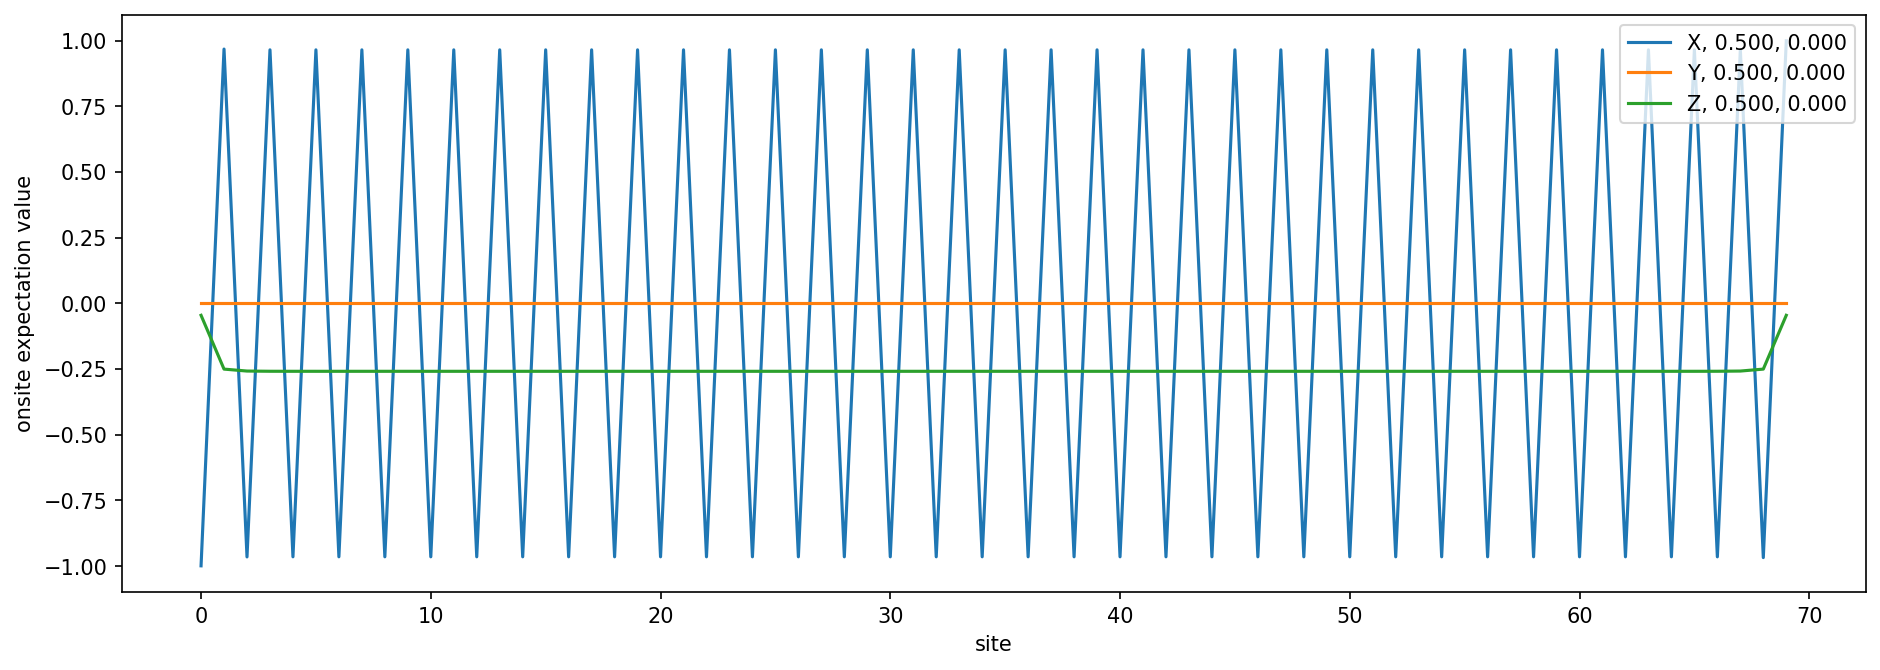

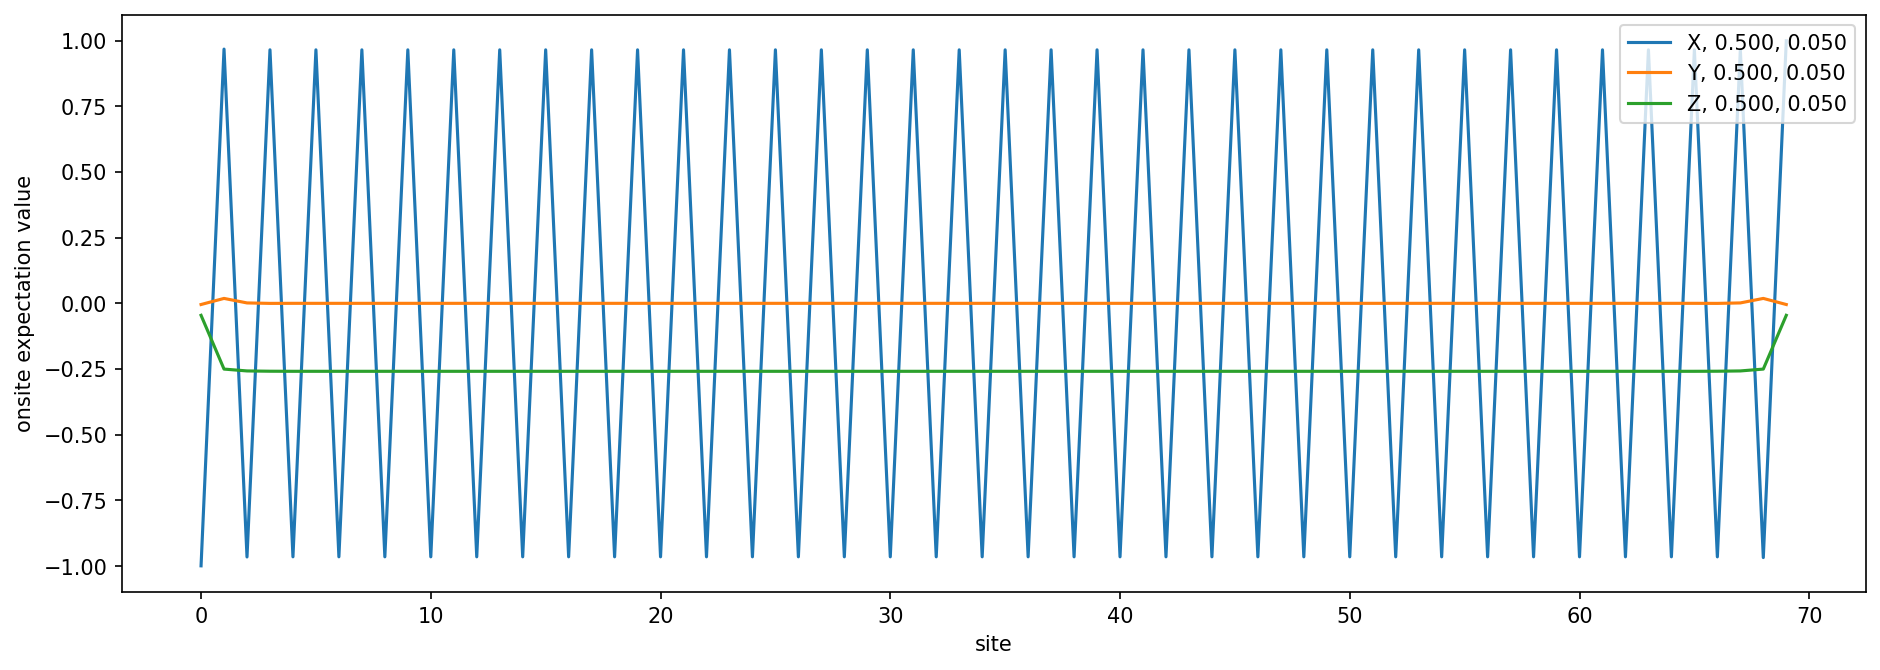

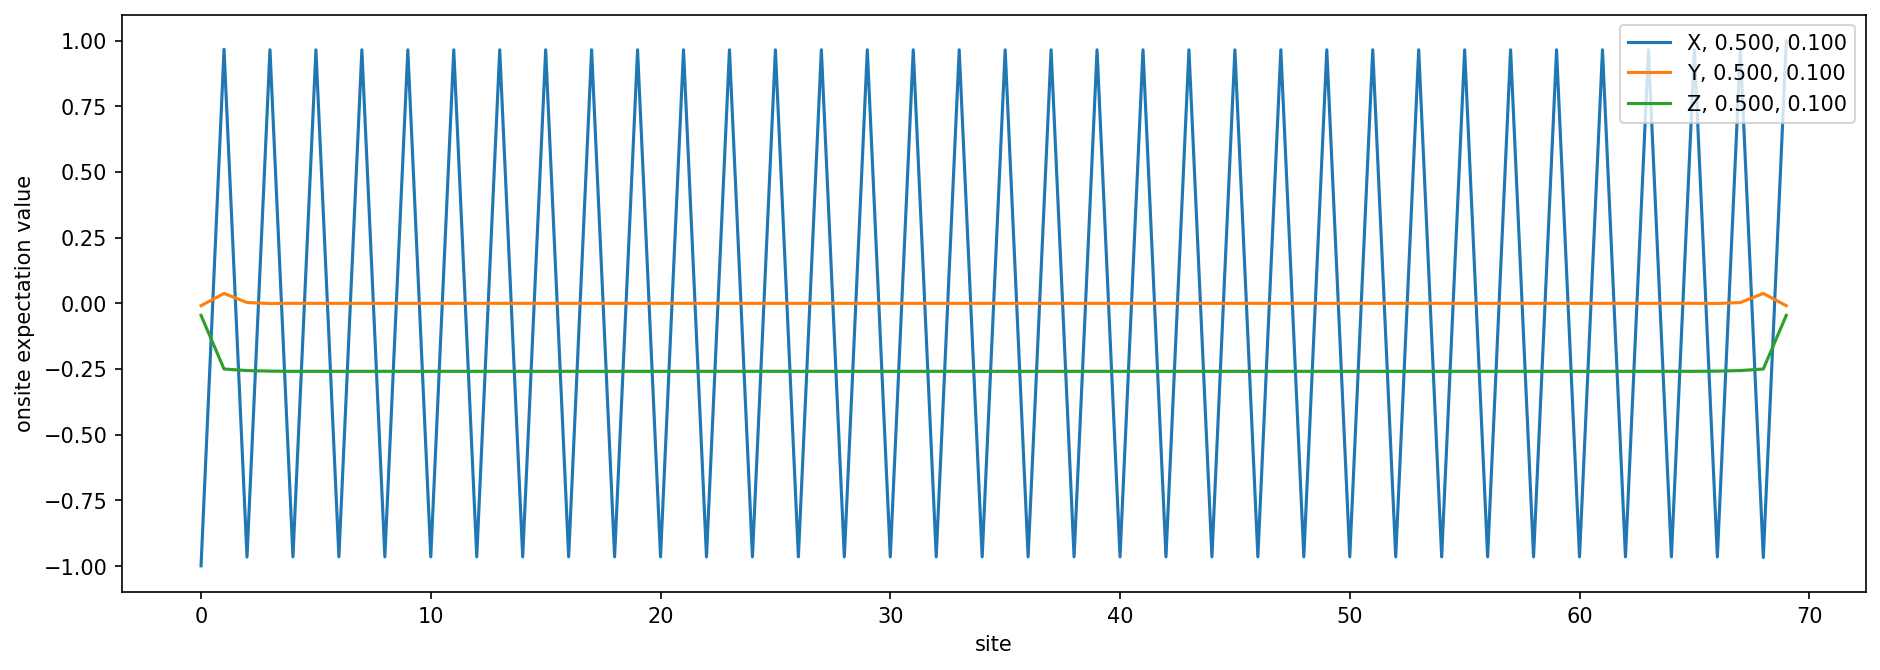

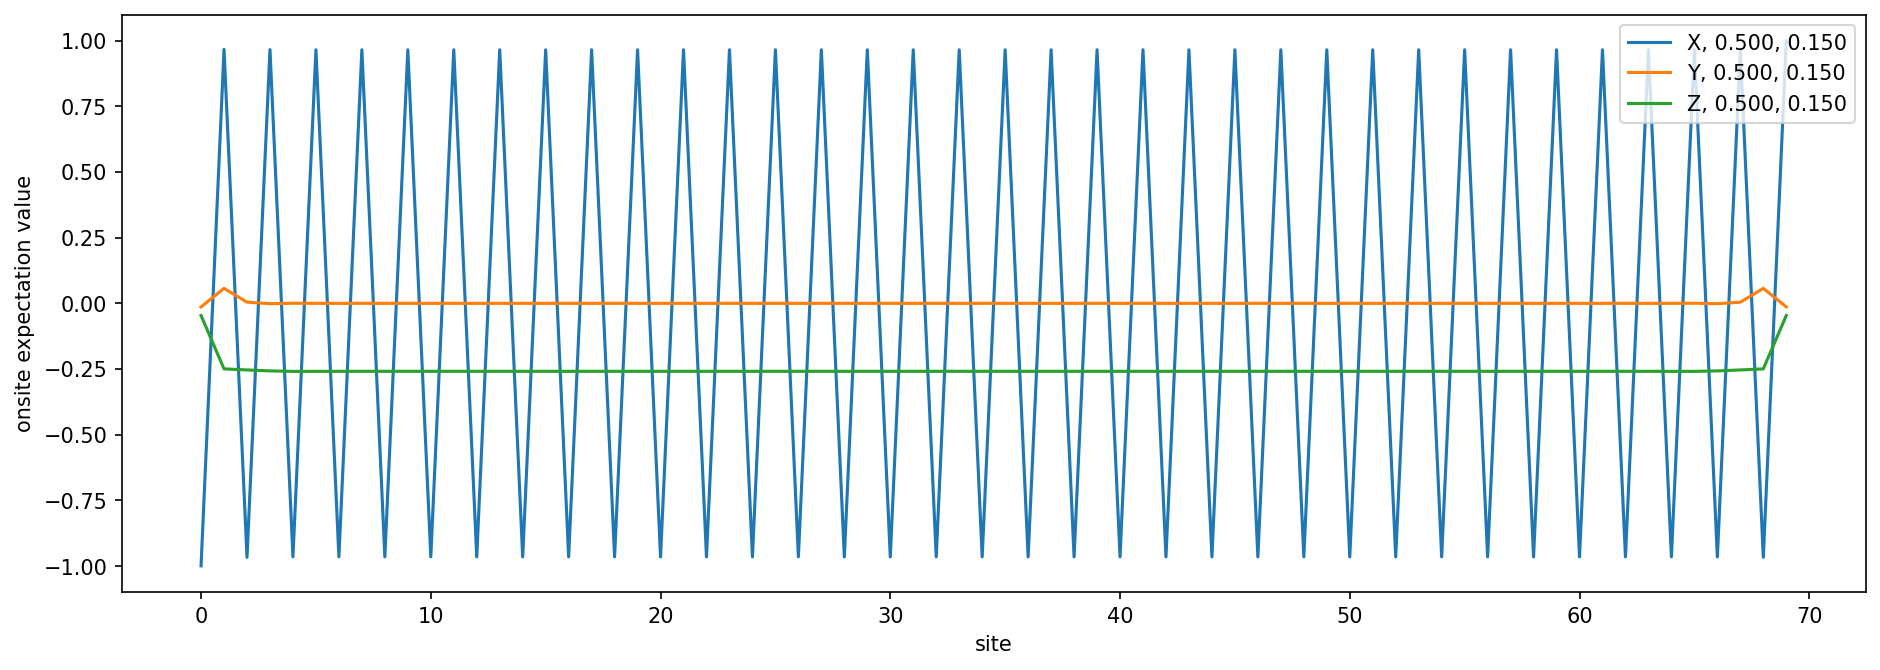

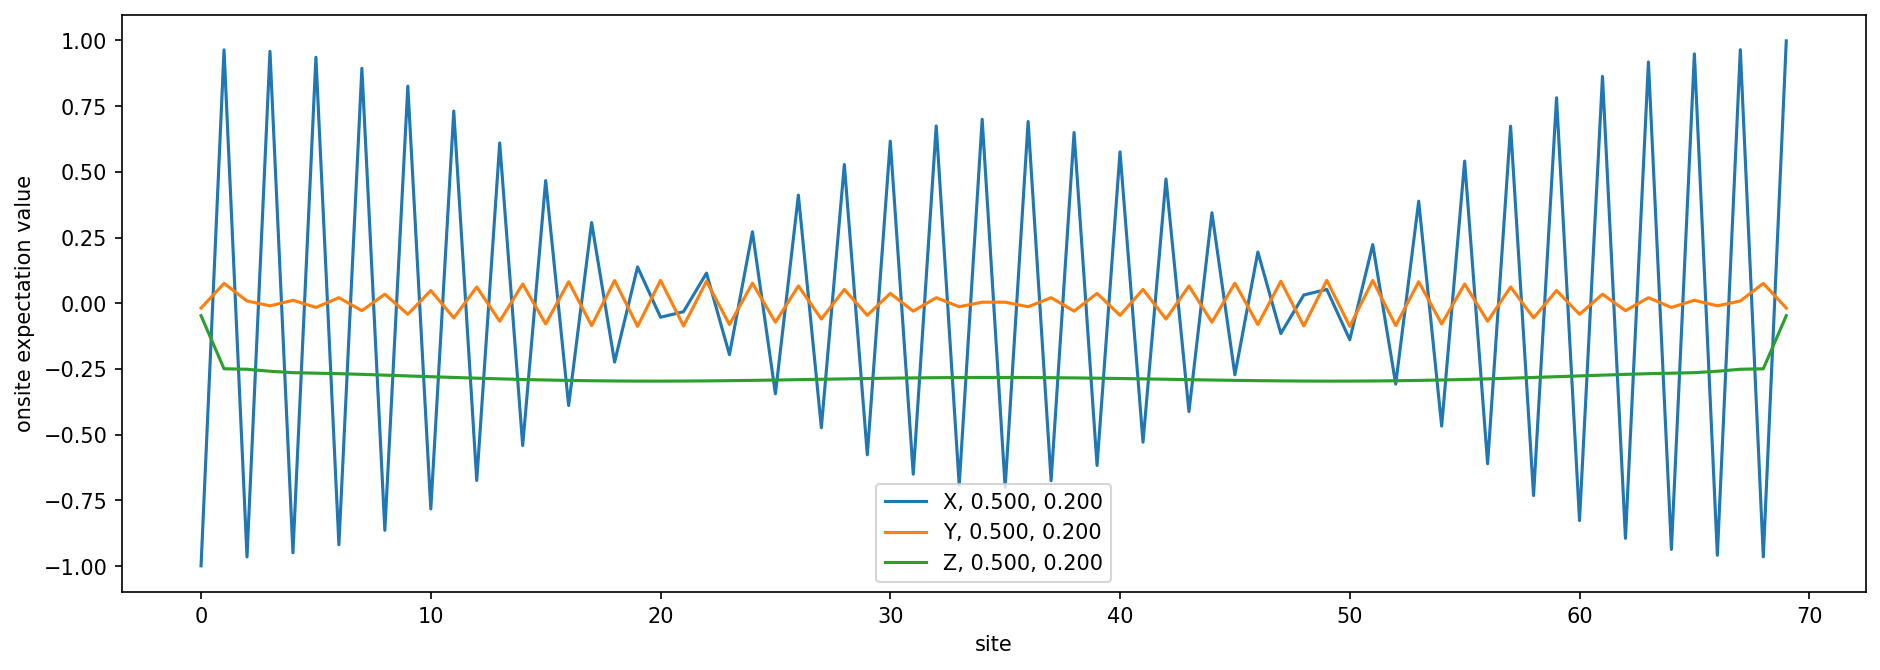

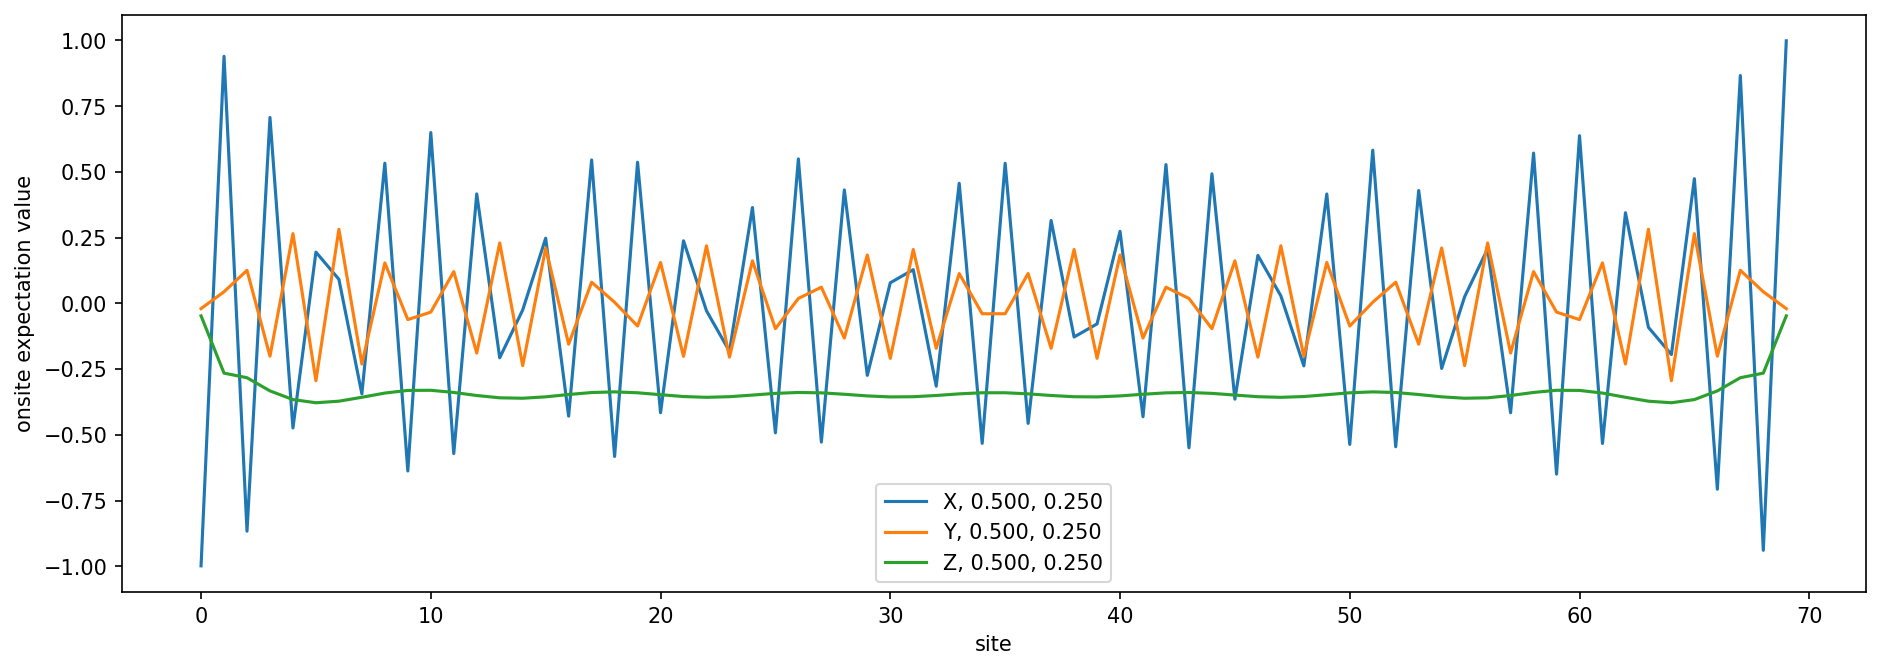

  warnings.warn(msg.format(keys=sorted(unused), name=self.name))



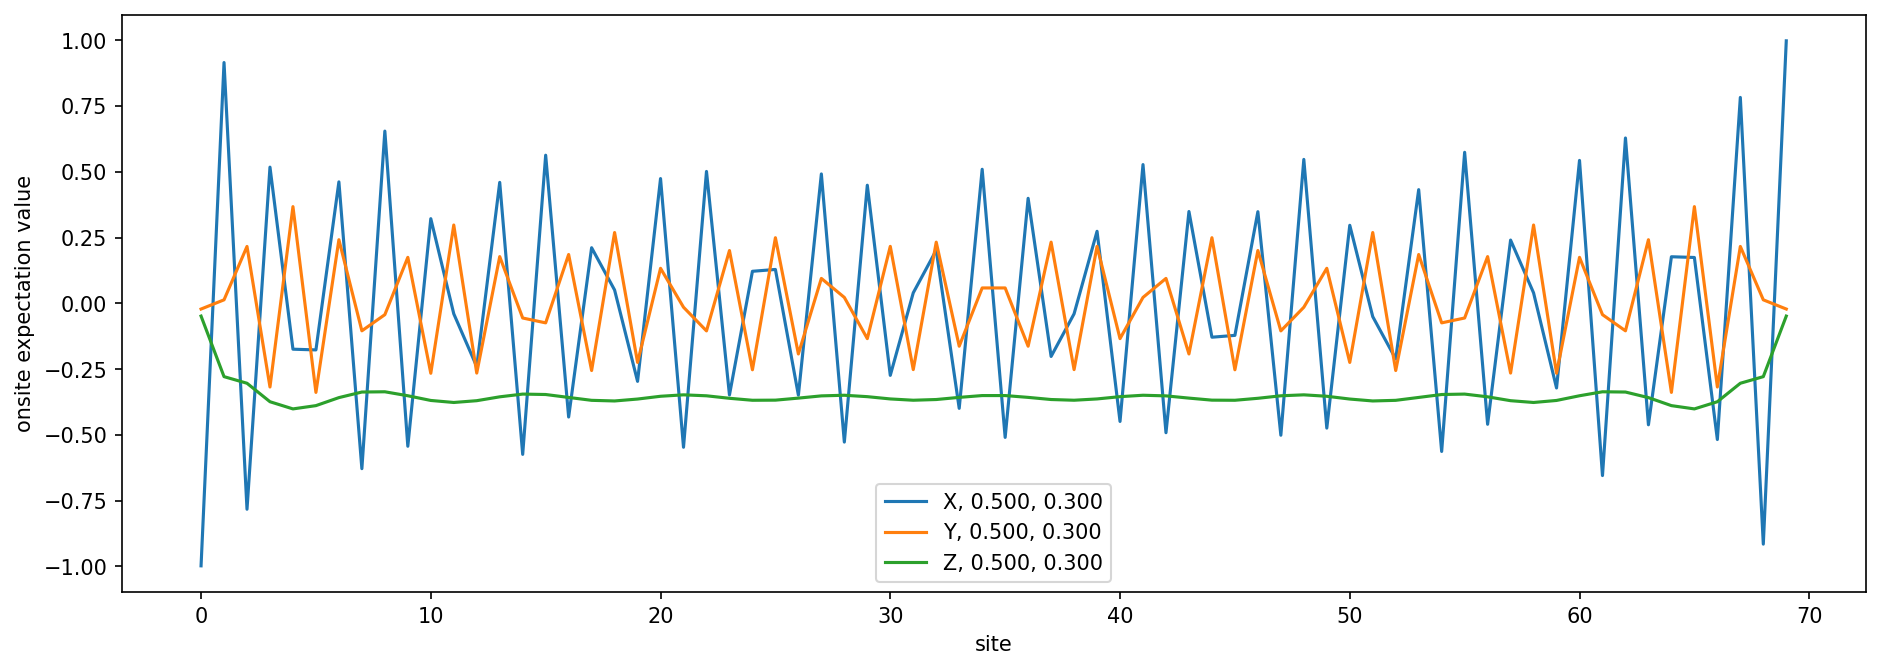

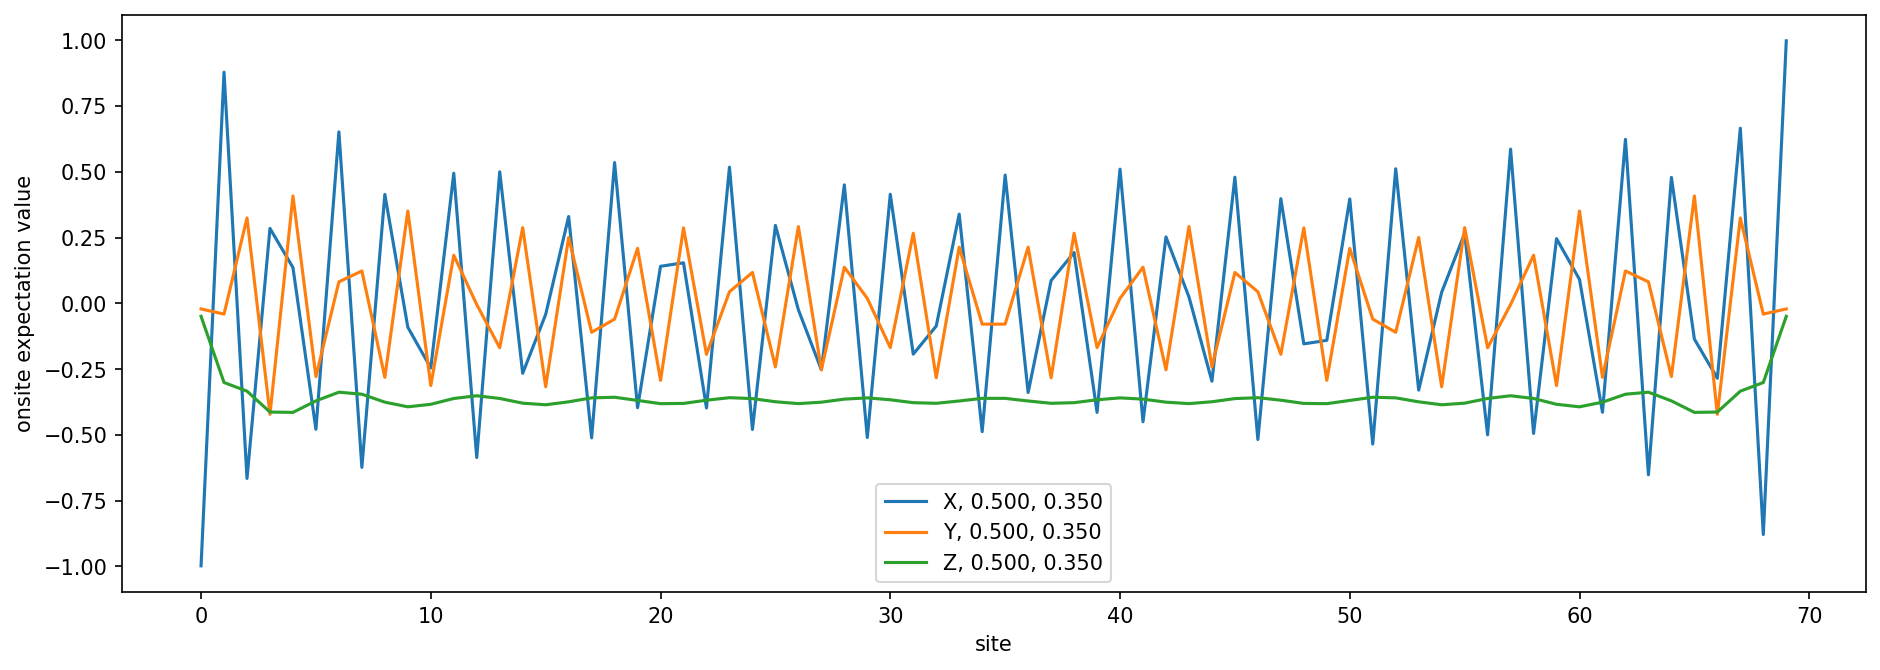

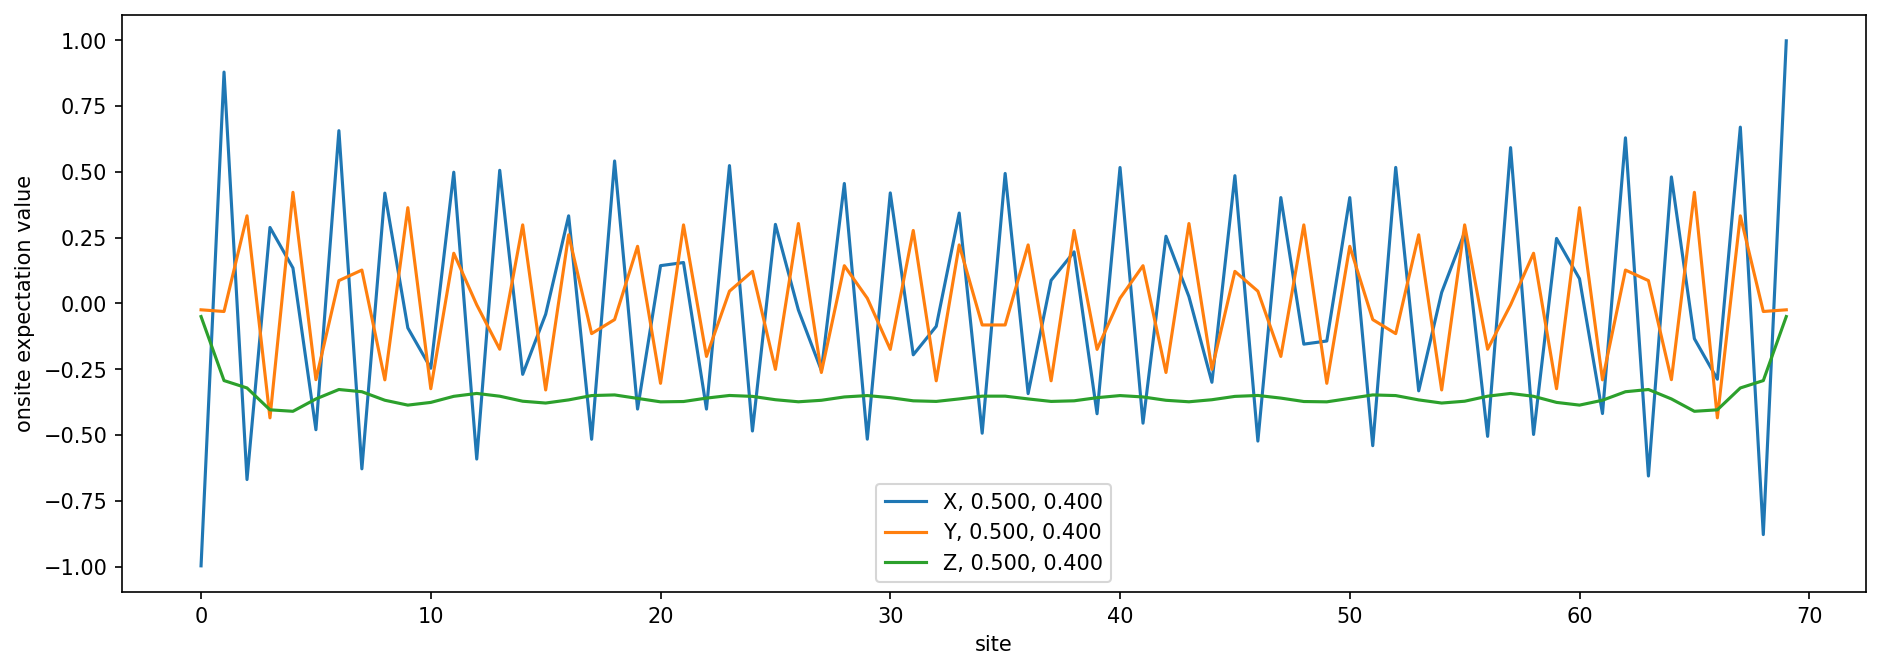

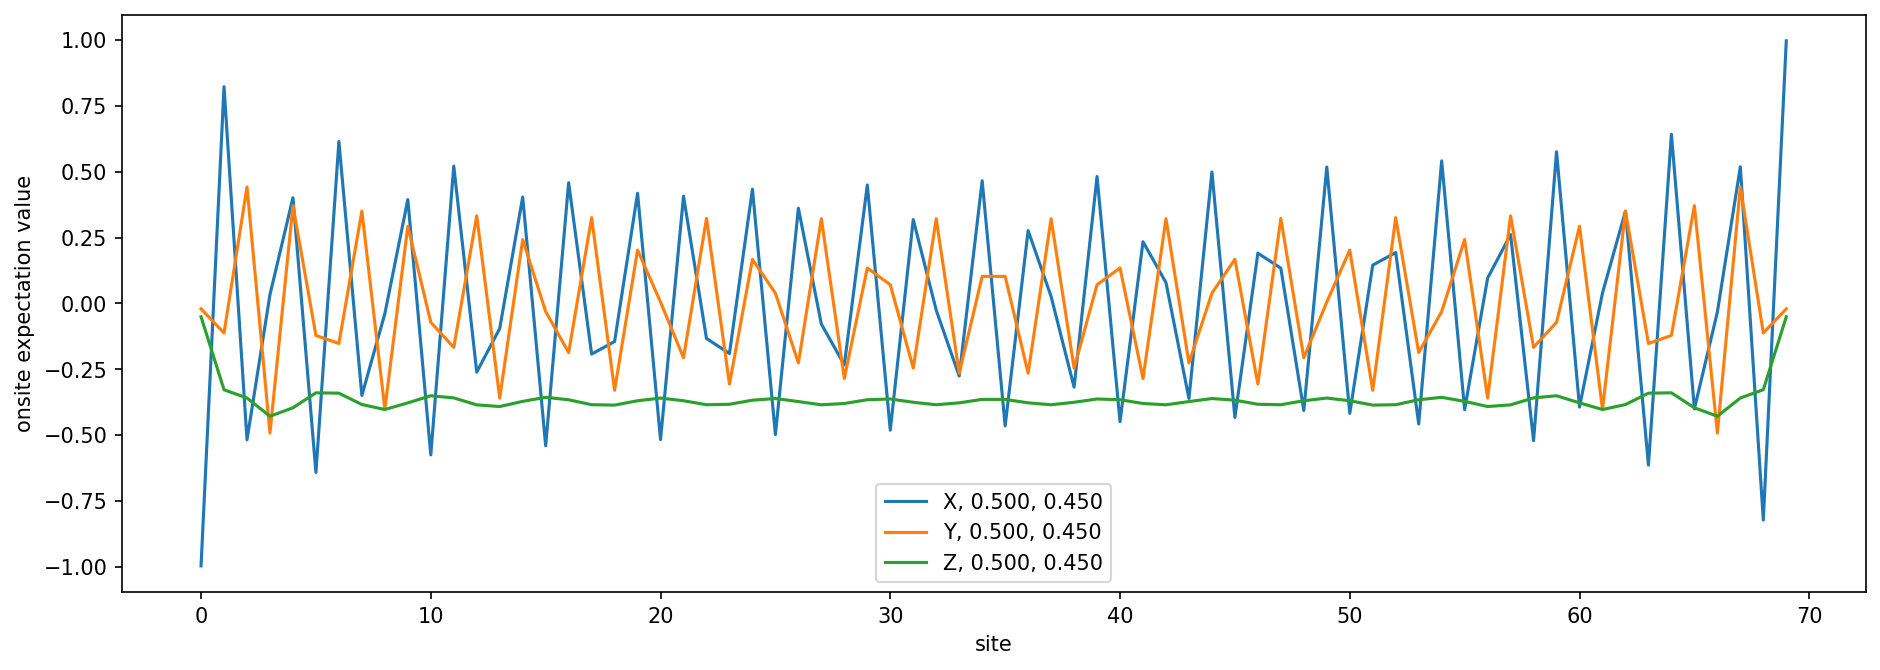

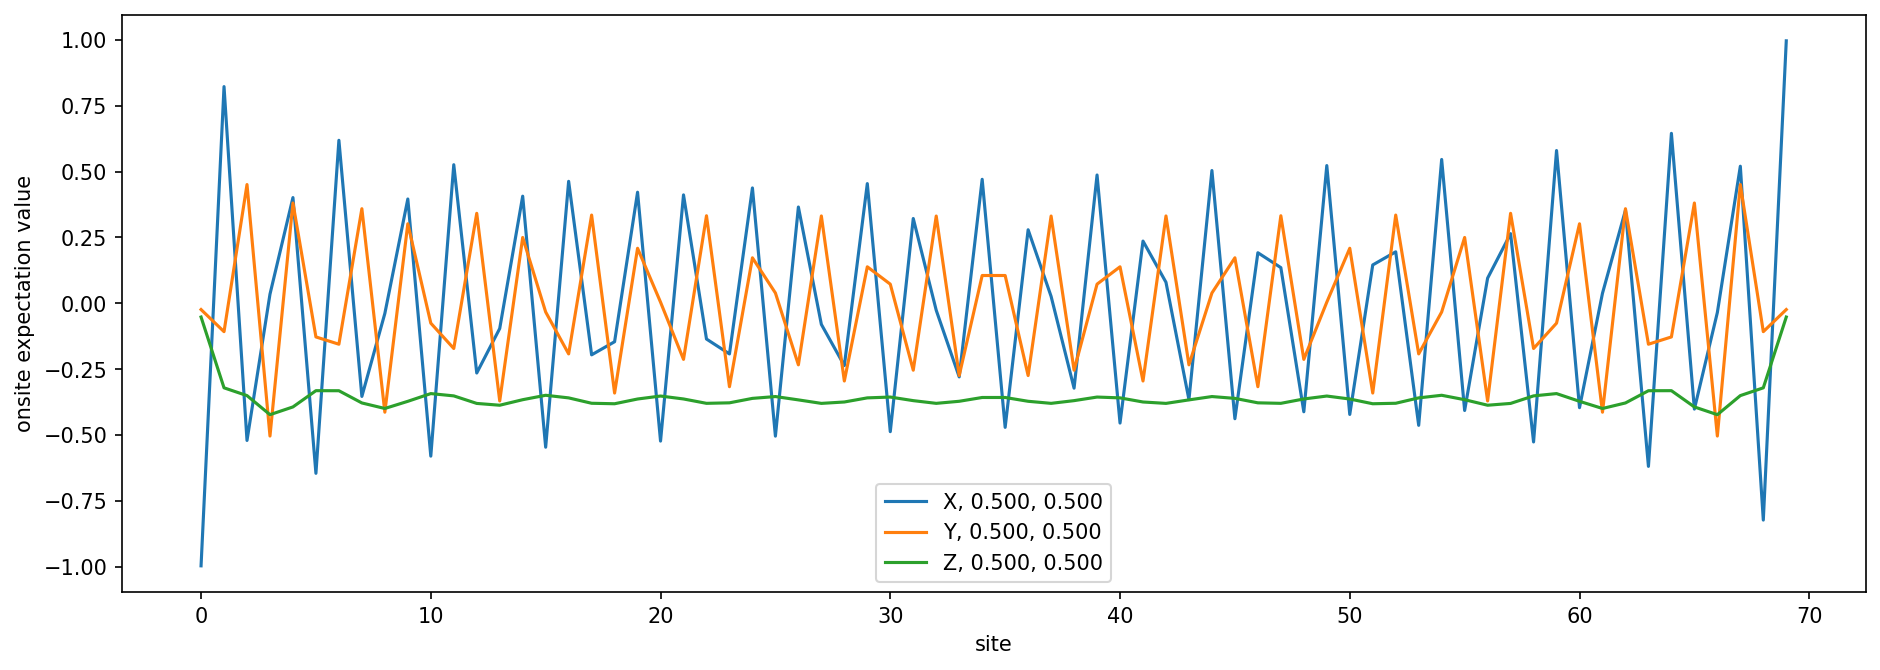

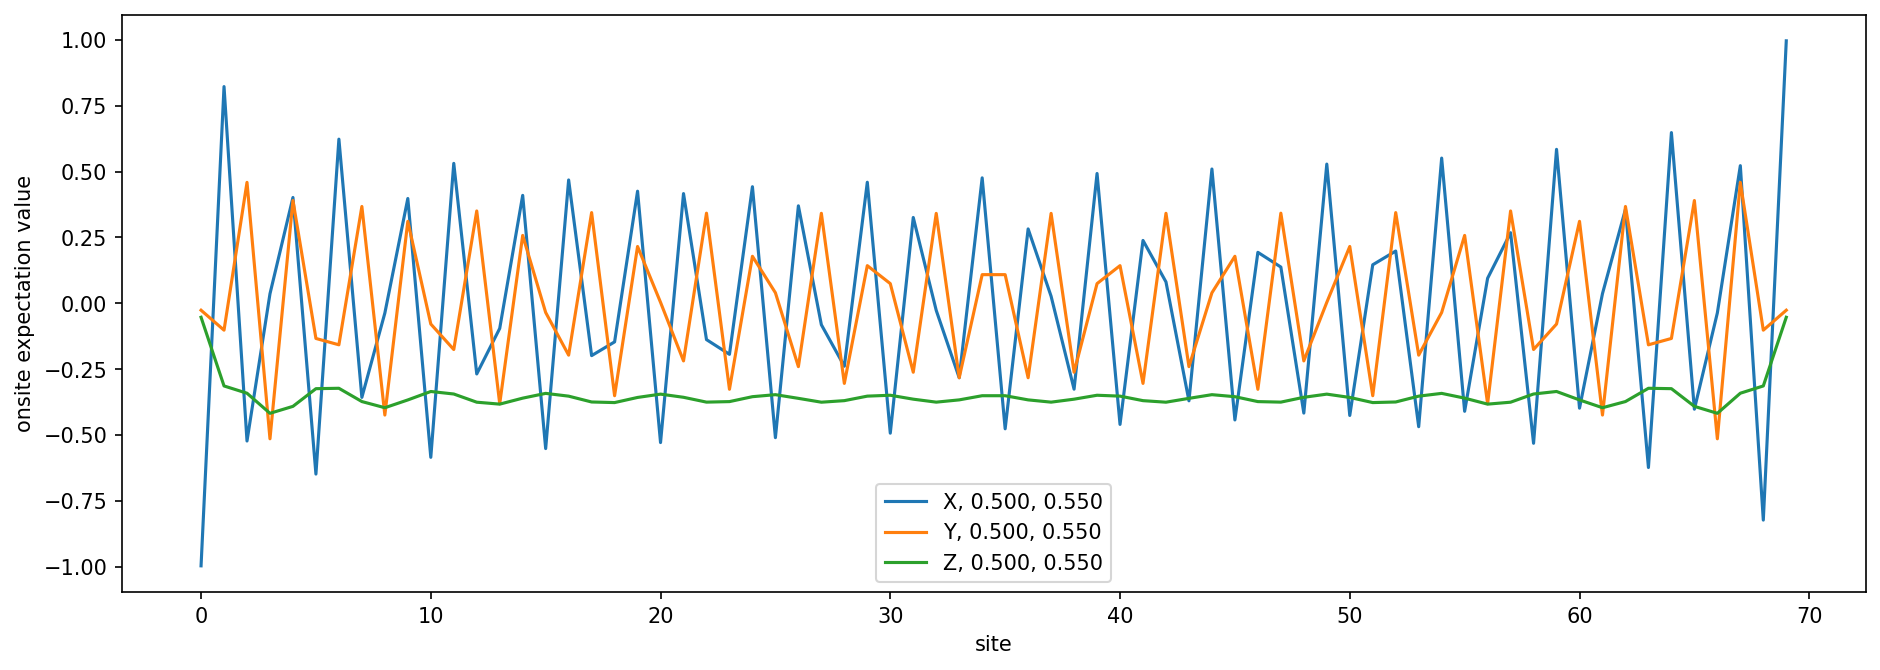

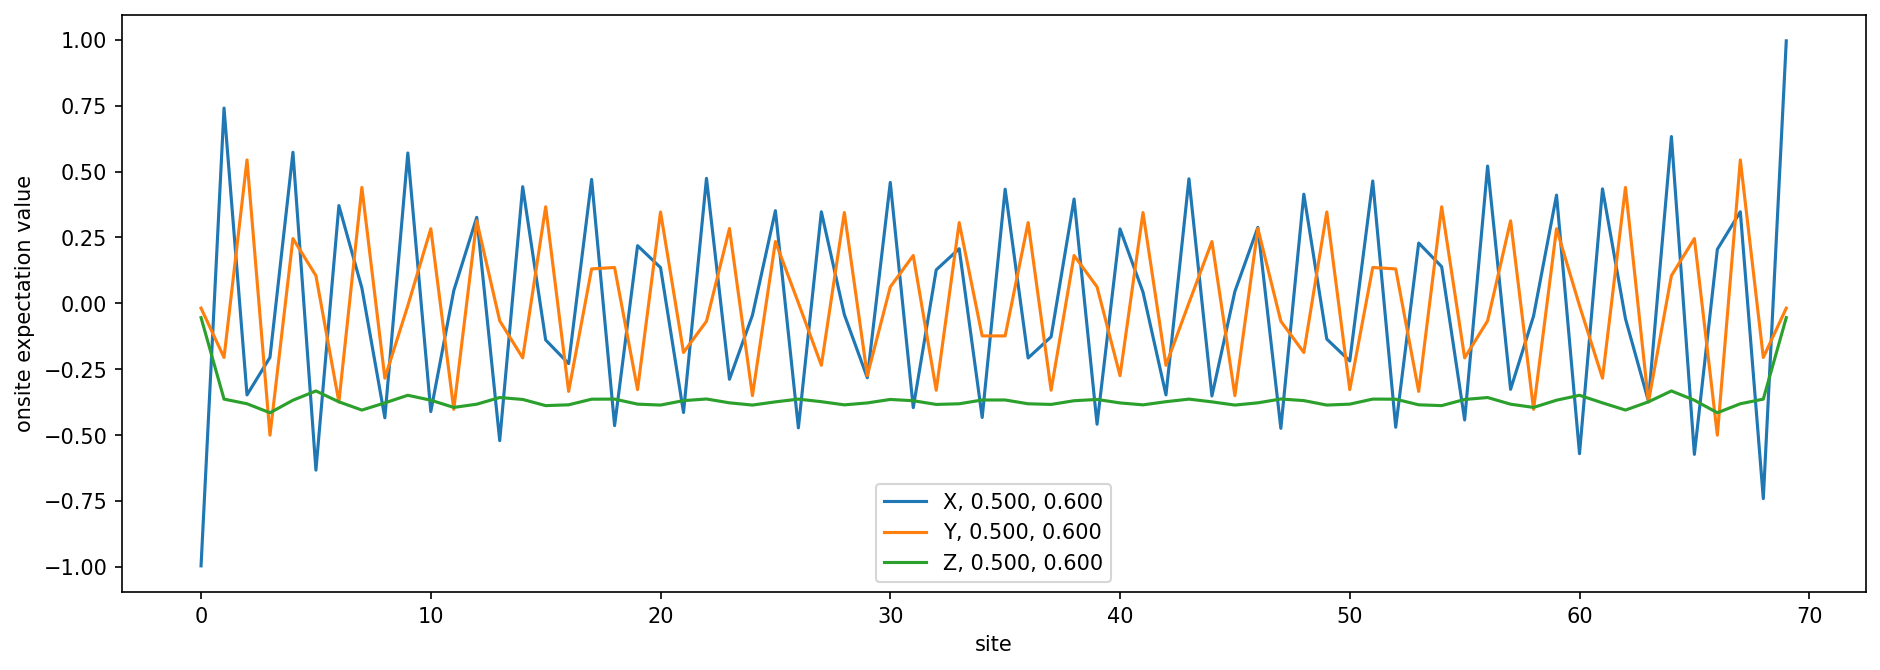

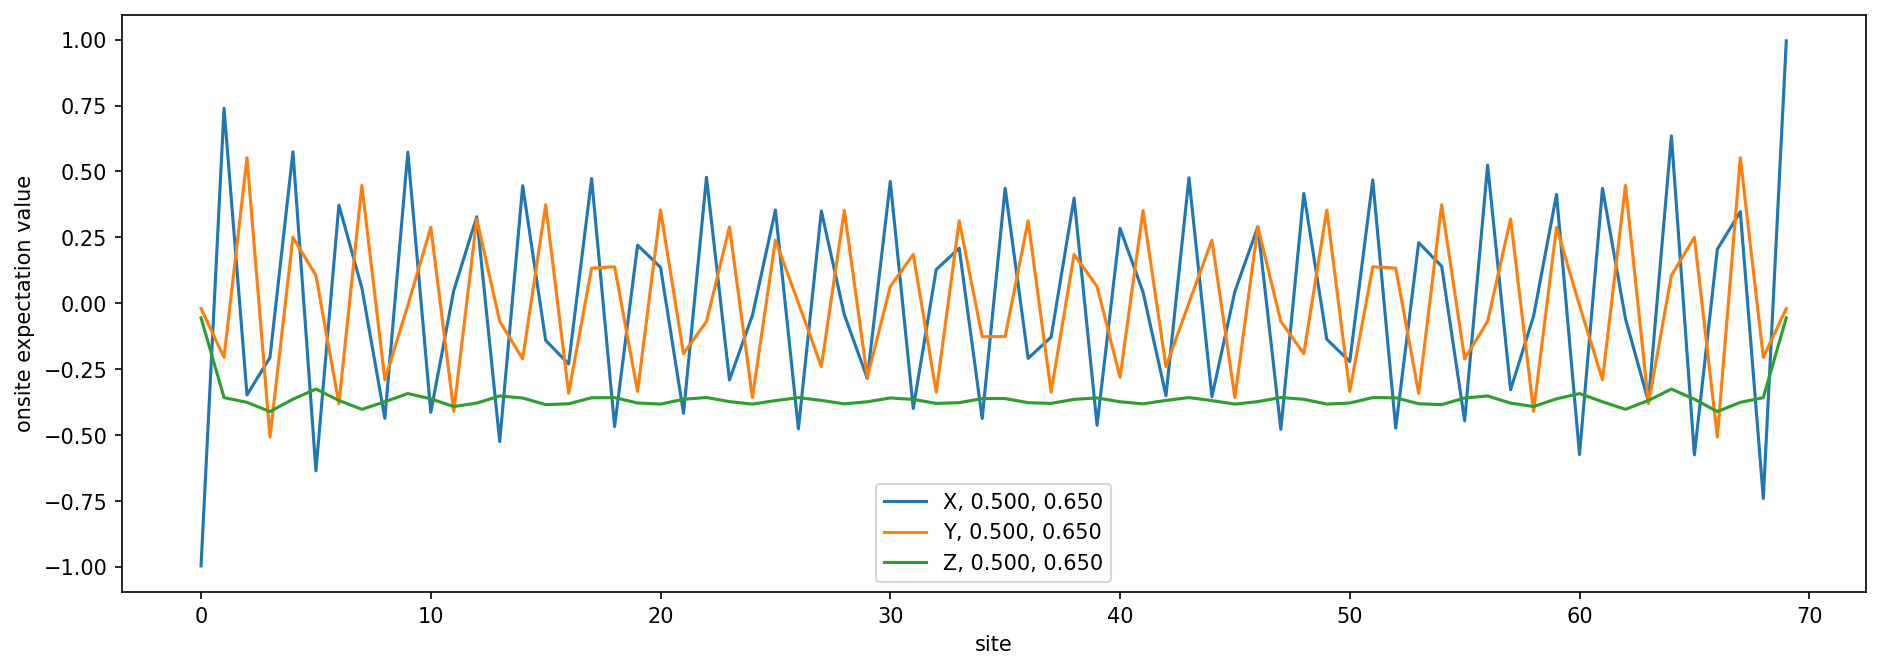

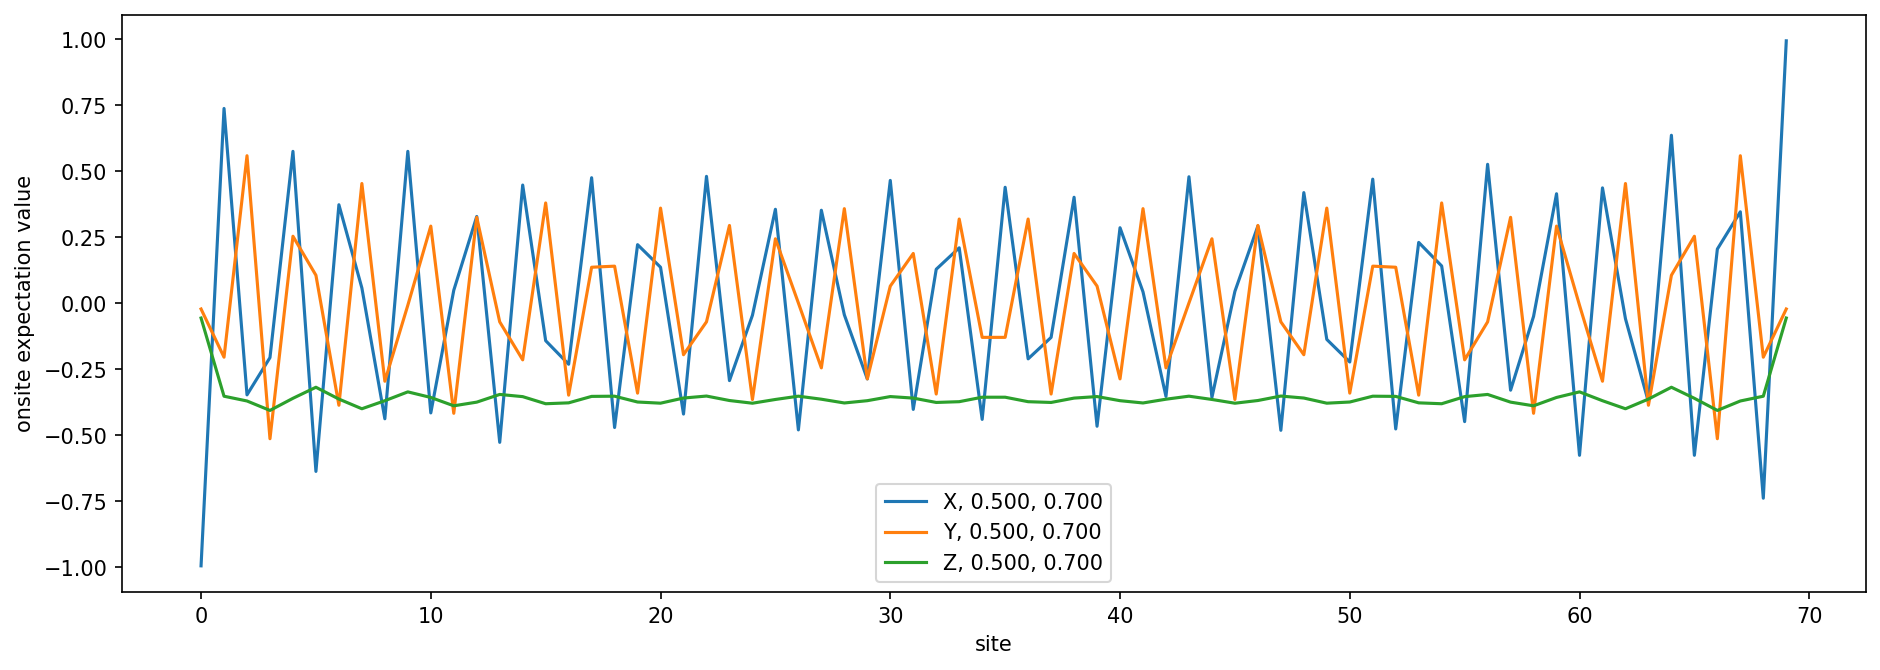

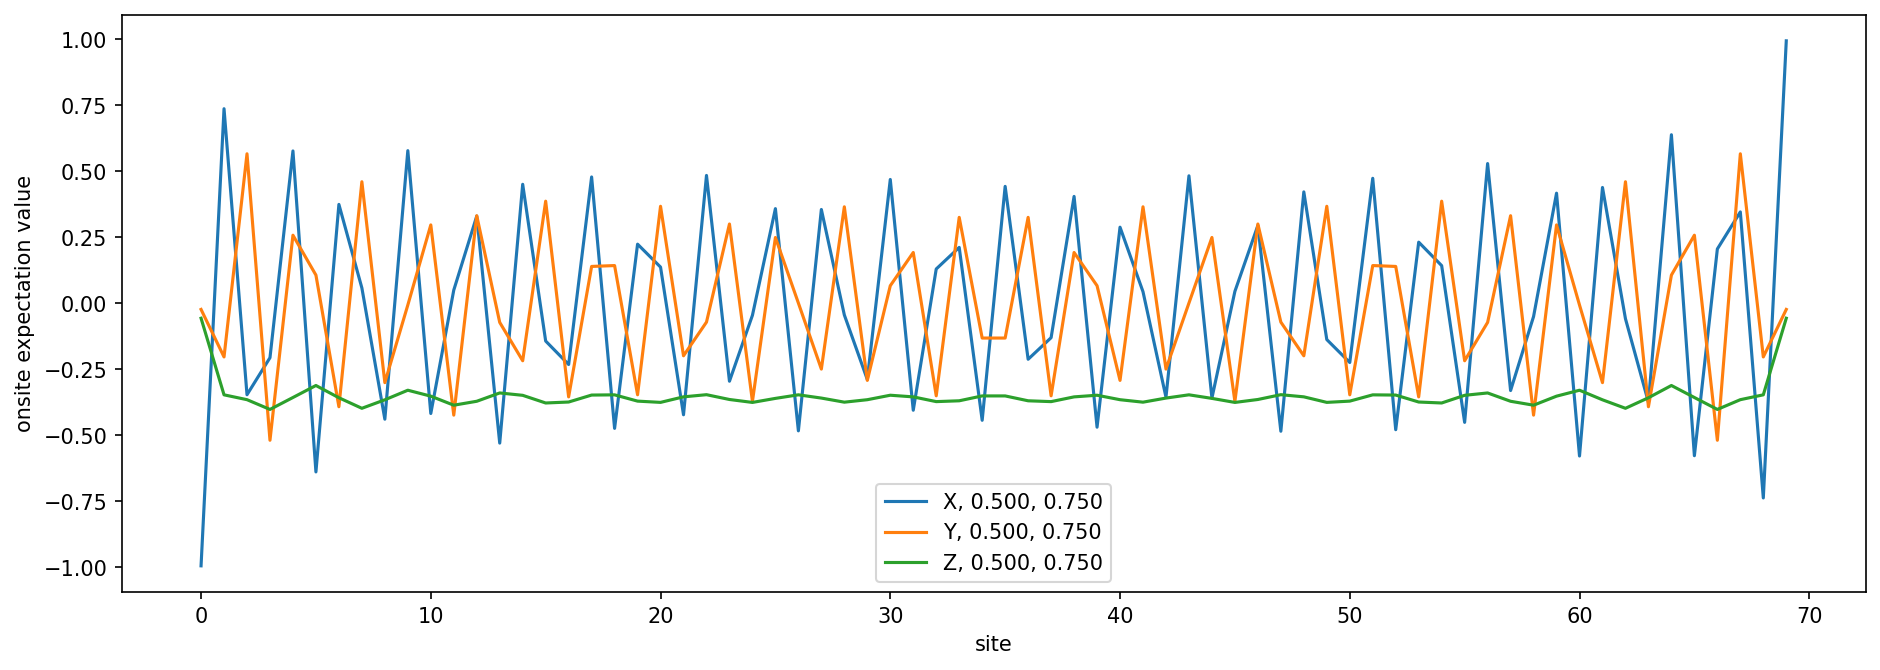

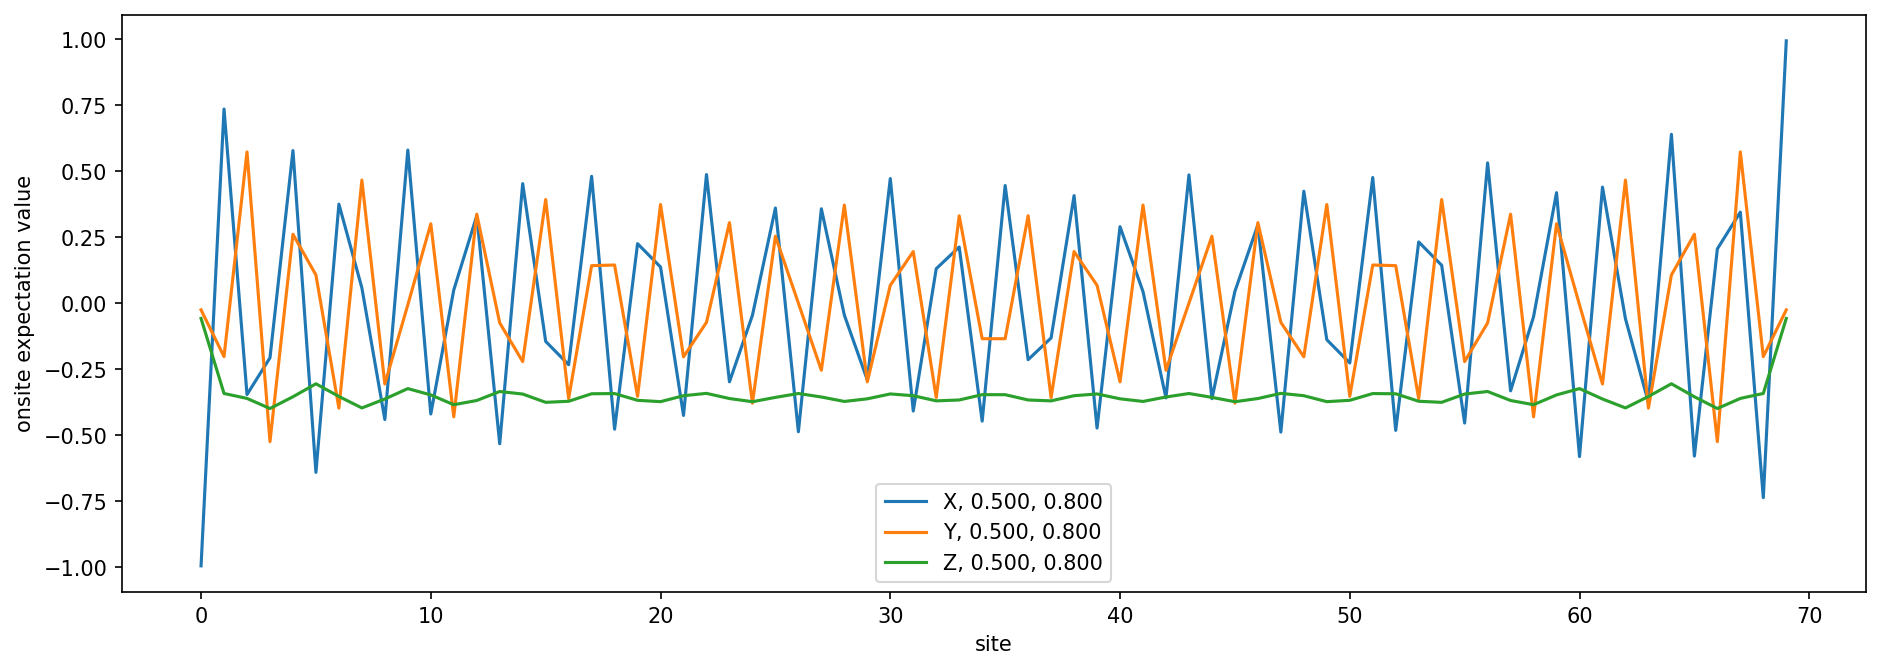

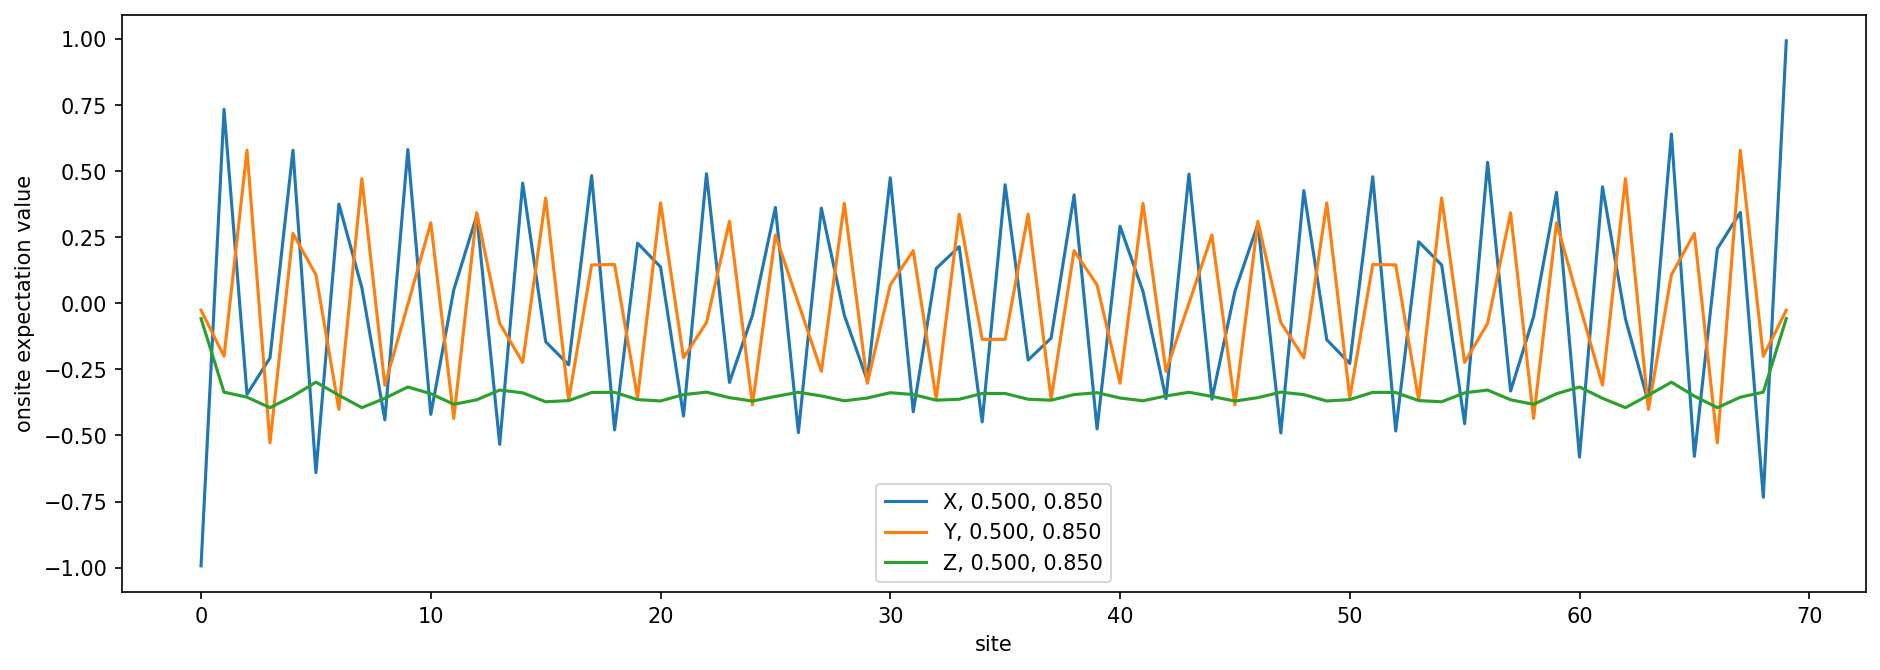

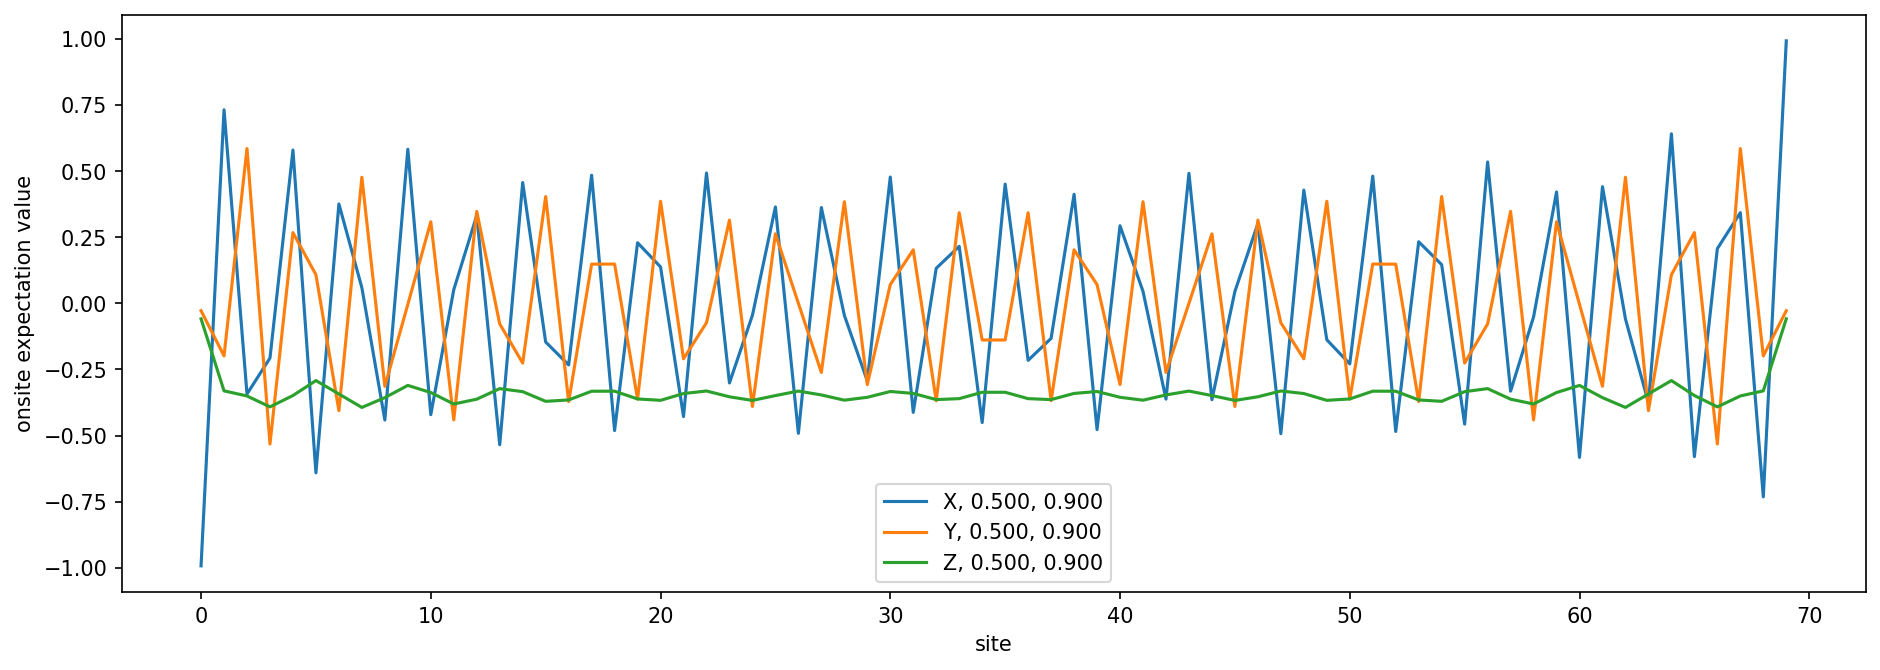

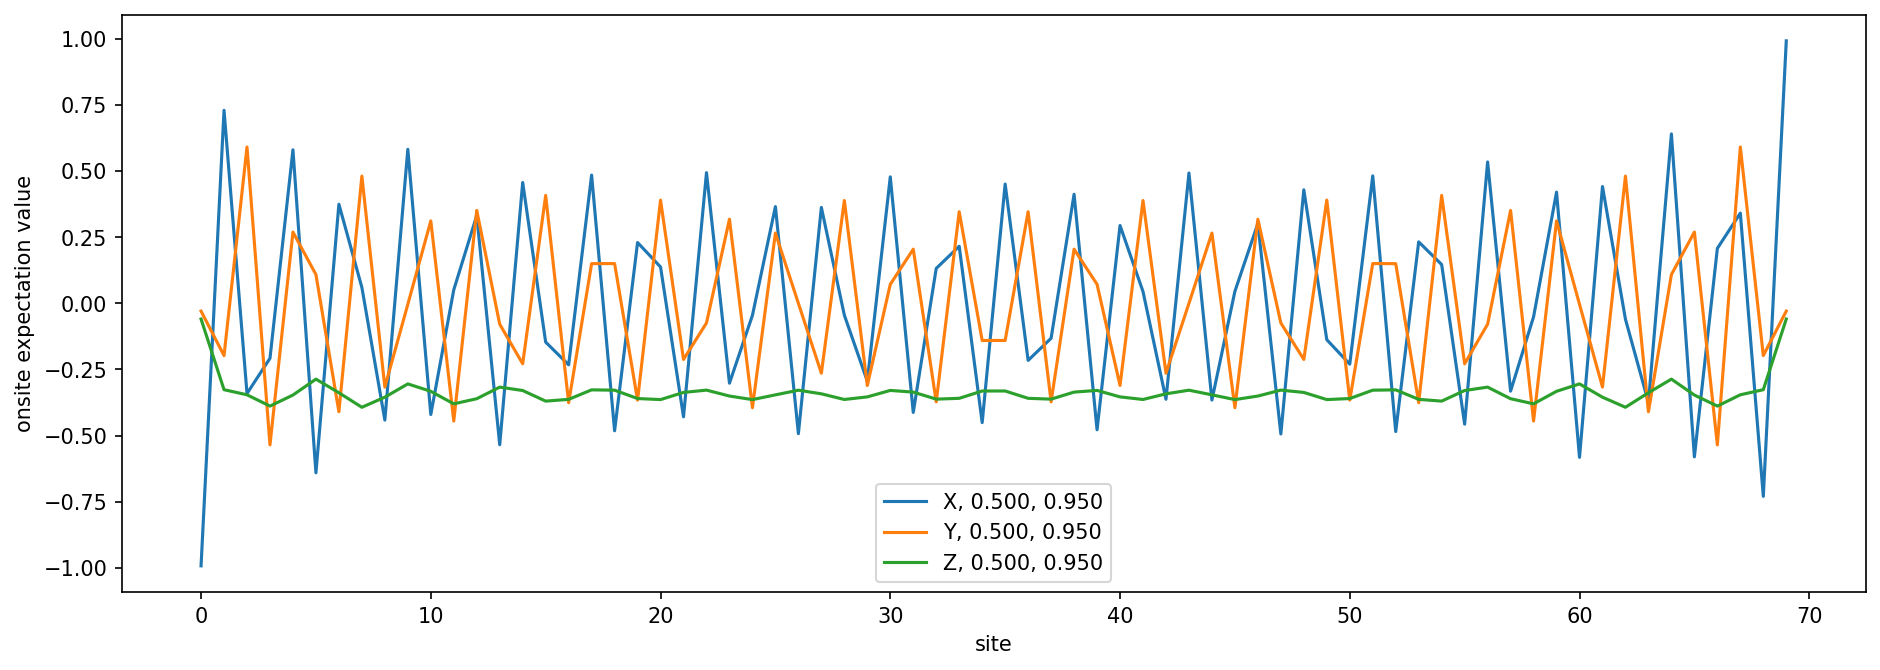

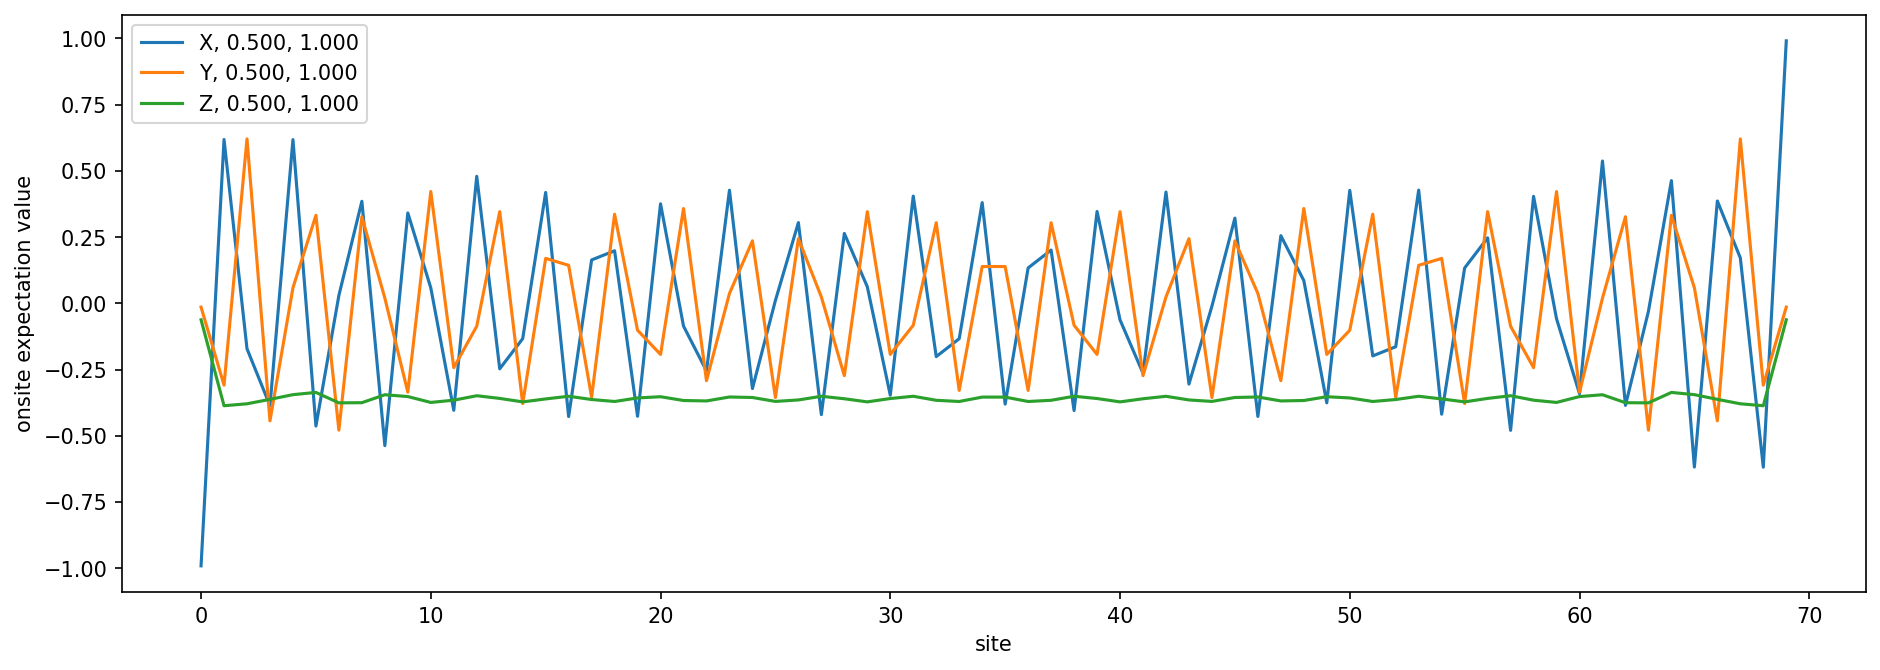

In [139]:
# onsite expectation values
h=0.5
filename = os.path.join(os.getcwd(), "L70-full", f"h_{h}")
print(filename)

for i in sorted(os.listdir(filename)):

    plt.figure(figsize=(15, 5))
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    i = os.path.splitext(i)[0]
    h, k = i.split("_")
    x = np.arange(psi.L)
    X = psi.expectation_value("Sigmax")
    Z = psi.expectation_value("Sigmaz")
    Y = psi.expectation_value("Sigmay")
    
    plt.plot(x, X, label=f"X, {h}, {k}")
    plt.plot(x, Y, label=f"Y, {h}, {k}")
    plt.plot(x, Z, label=f"Z, {h}, {k}")
   
    plt.xlabel("site")
    plt.ylabel("onsite expectation value")
    plt.legend()
    plt.show()

## Correlation Functions

/home/ioannisangelotassioulas/Documents/master_thesis/books/TFIM
0.500_0.000.pkl
0.500_0.100.pkl
0.500_0.200.pkl
0.500_0.300.pkl
0.500_0.400.pkl


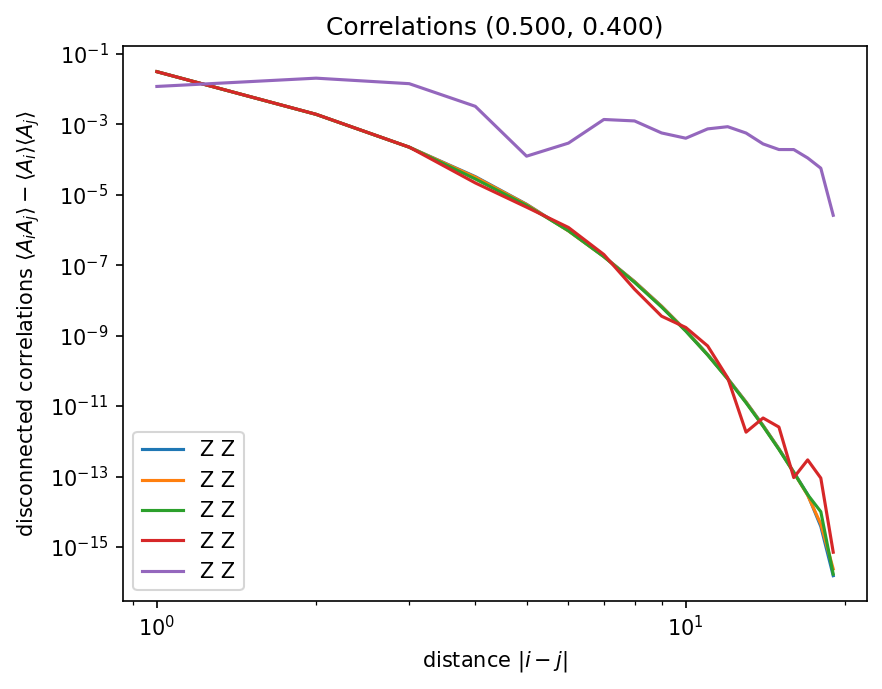

In [43]:
# correlation functions

print(filename)
plt.figure()

for i in sorted(os.listdir(filename)):
    print(i)
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    
    i = os.path.splitext(i)[0]
    h, k = i.split("_")

    X = psi.expectation_value("Sigmax")
    Y = psi.expectation_value("Sigmay")
    Z = psi.expectation_value("Sigmaz")


    i0 = psi.L // 2  # for fixed `i`
    j = np.arange(i0 + 1, psi.L)

    # XX = psi.term_correlation_function_right([("Sigmax", 0)], [("Sigmax", 0)], i_L=i0, j_R=j)
    # XX_disc = XX - X[i0] * X[j]

    YY = psi.term_correlation_function_right([("Sigmay", 0)], [("Sigmay", 0)], i_L=i0, j_R=j)
    YY_disc = YY - Y[i0] * Y[j]

    ZZ = psi.term_correlation_function_right([("Sigmaz", 0)], [("Sigmaz", 0)], i_L=i0, j_R=j)
    ZZ_disc = ZZ - Z[i0] * Z[j]

    # XY = psi.term_correlation_function_right([("Sigmax", 0)], [("Sigmay", 0)], i_L=i0, j_R=j)
    # XY_disc = XY - X[i0] * Y[j]

    # XZ = psi.term_correlation_function_right([("Sigmax", 0)], [("Sigmaz", 0)], i_L=i0, j_R=j)
    # XZ_disc = XZ - X[i0] * Z[j]

    # YZ = psi.term_correlation_function_right([("Sigmay", 0)], [("Sigmaz", 0)], i_L=i0, j_R=j)
    # YZ_disc = YZ - Y[i0] * Z[j]


    dx = j - i0
    # plt.plot(dx, np.abs(XX_disc), label=f"{h}, {k}")
    # plt.plot(dx, np.abs(YY_disc), label="Y Y")
    plt.plot(dx, np.abs(ZZ_disc), label="Z Z")
    # plt.plot(dx, XY_disc, label="X Y")
    # plt.plot(dx, XZ_disc, label="X Z")
    # plt.plot(dx, YZ_disc, label="Y Z")
    plt.xlabel(r"distance $|i-j|$")
    plt.ylabel(r"disconnected correlations $\langle A_i A_j\rangle - \langle A_i \rangle\langle A_j\rangle$")
    plt.title(f"Correlations ({h}, {k})")
    plt.legend()
    plt.loglog()
plt.show()

## Entanglement Entropy

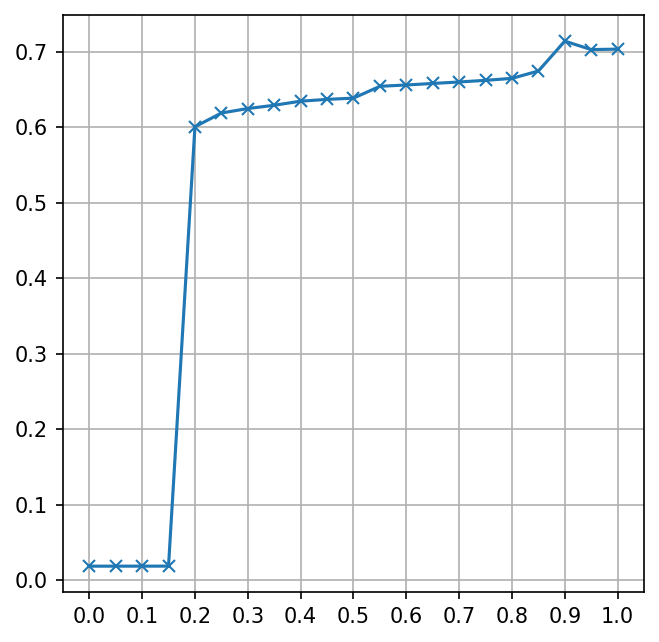

In [137]:
h=0.75
sim = f"h_{h}"

filename = os.path.join(os.getcwd(), "L70-full", sim)

mid_chain_entropy = []
ks = []
plt.figure(figsize=(5,5))
for i in sorted(os.listdir(filename)):
    j=os.path.splitext(i)[0]
    h, k = j.split("_")
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']

    L = psi.L
    S = psi.entanglement_entropy()

    ks.append(float(k))
    mid_chain_entropy.append(S[L//2])
plt.plot(ks,mid_chain_entropy, marker="x")
plt.xticks(ks[::2])
plt.grid()



1.000_0.000.pkl
extraced central charge 0.48260 with residuum 6.06e-09


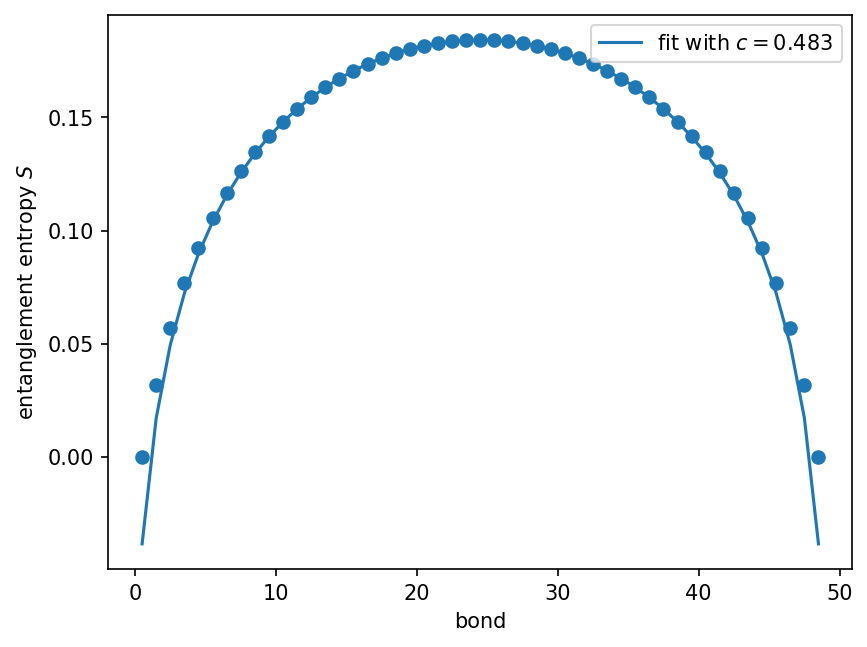

1.000_0.100.pkl
extraced central charge 0.49244 with residuum 3.50e-09


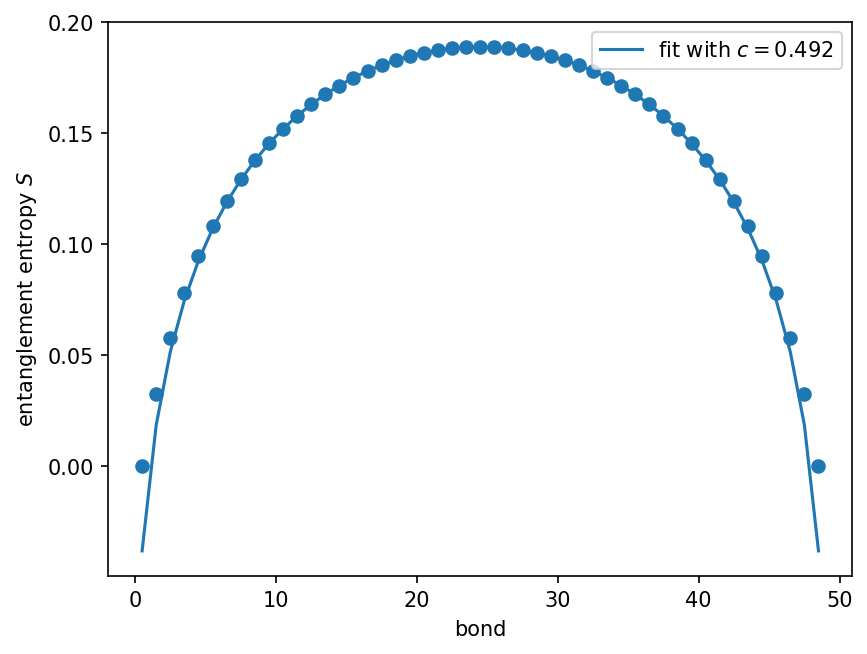

1.000_0.200.pkl
extraced central charge 0.53795 with residuum 1.34e-09


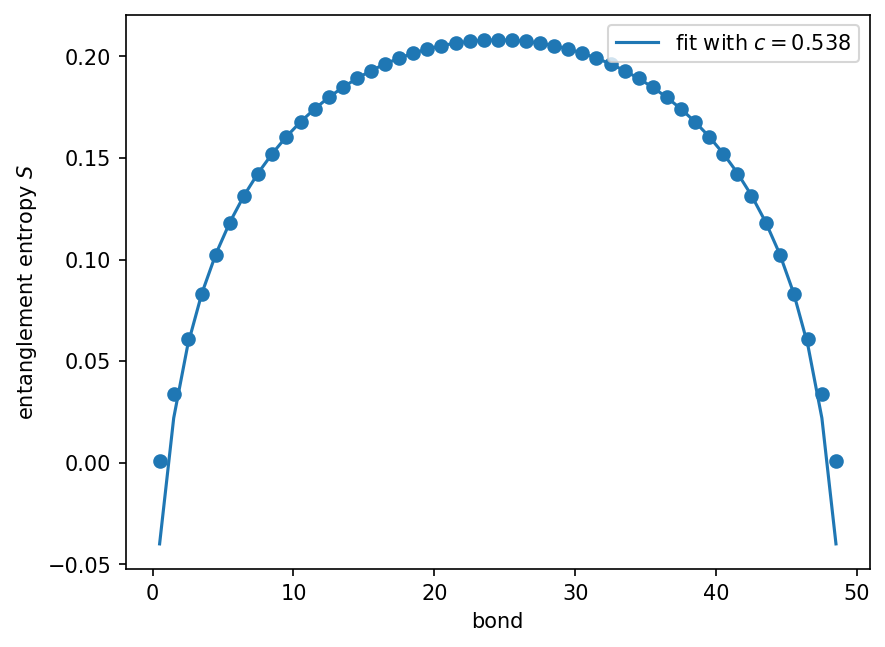

1.000_0.300.pkl
extraced central charge -2.52746 with residuum 7.36e-02


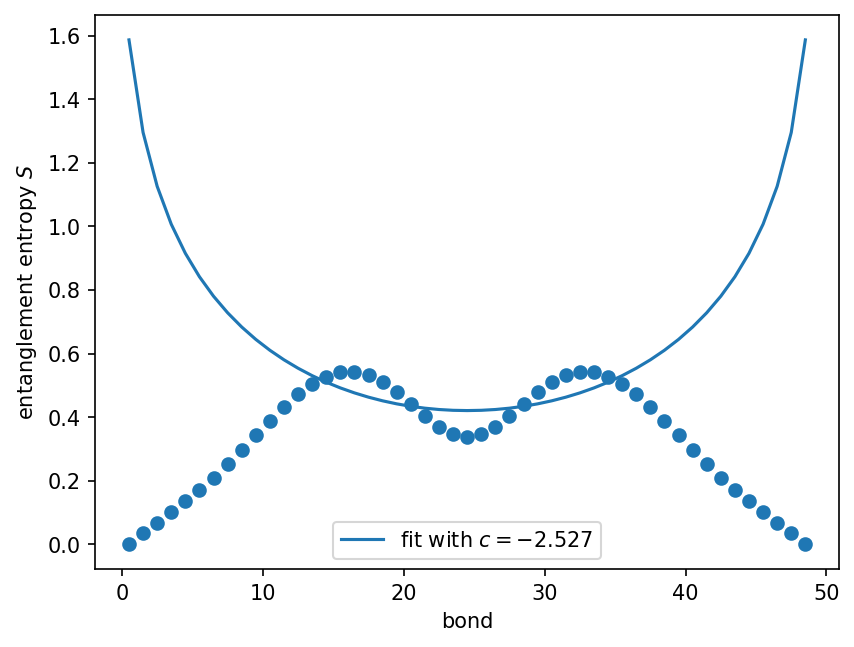

In [83]:
filename = os.path.join(os.getcwd(), "TFIM2")

def linfun(x, c, consta):
    return (c/6) * x + consta

def conformal_distance(L, pos):
    return np.log((2*L/(np.pi) * np.sin((np.pi*pos)/L)))

for i in sorted(os.listdir(filename)):
    print(i)
    loc = os.path.join(filename, i)
    with open(loc, 'rb') as f:
        data = pickle.load(f)
        psi = data['psi']
    S = psi.entanglement_entropy()

    bonds = np.arange(0.5, psi.L-1)
    cut = 1

    conformal_bonds   = conformal_distance(psi.L, bonds[psi.L//2])
    conformal_entropy = S[psi.L//2:]
    # popt, pcov = curve_fit(linfun, conformal_bonds[cut:-cut], conformal_entropy[cut:-cut])
    # plt.plot(conformal_bonds[cut:-cut], conformal_entropy[cut:-cut], 'o', label="S")
    # plt.plot(conformal_bonds[cut:-cut], linfun(conformal_bonds[cut:-cut], *popt), label=f"{popt[0]}")

    plt.scatter(bonds, S)
    # preform fit to extract the central charge
    central_charge, const, res = tenpy.tools.fit.central_charge_from_S_profile(psi)
    fit = tenpy.tools.fit.entropy_profile_from_CFT(bonds+0.5, psi.L, central_charge, const)
    print(f"extraced central charge {central_charge:.5f} with residuum {res:.2e}")
    plt.plot(bonds, fit, label=f"fit with $c={central_charge:.3f}$")
    plt.xlabel("bond")
    plt.ylabel("entanglement entropy $S$")
    plt.legend()
    plt.show()